# **Tantangan 1: Data Cleansing**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

* **`pandas` & `numpy`**: Digunakan untuk manipulasi struktur tabel data (DataFrame) serta komputasi numerik secara efisien.
* **`matplotlib.pyplot` & `seaborn`**: Kombinasi library visualisasi data terpopuler di Python. `Seaborn` digunakan untuk menghasilkan visualisasi yang estetis dengan sintaks sederhana, sementara `Matplotlib` berfungsi sebagai fondasi kontrol penuh elemen grafik.

In [11]:
# Set style untuk visualisasi agar terlihat profesional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

**Pengaturan Tema (`sns.set_theme`) & Ukuran (`plt.rcParams`)**: Mengatur tema latar belakang grafik menjadi `"whitegrid"` (garis pandu putih) dan menetapkan ukuran default seluruh grafik sebesar 12x6 inci agar tampilan visualisasi terlihat seragam, bersih, dan profesional saat dibaca.

In [12]:
# 1. Muat Dataset dengan format Excel (.xlsx) sesuai gambar panel Anda
file_path = "furniture_10k_FINAL.xlsx"
df = pd.read_excel(file_path)

print("--- Data Berhasil Dimuat ---")
print(f"Jumlah baris awal: {df.shape[0]} baris\n")

--- Data Berhasil Dimuat ---
Jumlah baris awal: 10000 baris



In [15]:
df.head(10)

,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address
0,2025-07-31,ORD00001,Customer_332,Kitchen Set,Dapur,9500000,1,0.0,9500000,60000,9560000,cancelled,"Kelurahan 120, Jakarta Pusat"
1,2025-11-03,ORD00002,Customer_1150,Nakas,Kamar Tidur,1000000,2,0.0,2000000,60000,2060000,completed,"Kelurahan 9, Jakarta Pusat"
2,2025-10-31,ORD00003,Customer_2122,Kursi Bar,Ruang Makan,1295000,2,0.0,2590000,60000,2650000,completed,"Kelurahan 108, Jakarta Pusat"
3,2025-06-19,ORD00004,Customer_2636,Kasur,Kamar Tidur,5500000,3,0.0,16500000,50000,16550000,completed,"Kelurahan 36, Bogor"
4,2025-06-19,ORD00005,Customer_3379,Meja Makan,Ruang Makan,3200000,3,0.0,9600000,60000,9660000,completed,"Kelurahan 73, Tangerang"
5,2025-01-11,ORD00006,Customer_793,Lemari Dapur,Dapur,1850000,1,0.0,1850000,60000,1910000,completed,"Kelurahan 176, Tangerang"
6,2025-12-05,ORD00007,Customer_469,Nakas,Kamar Tidur,1000000,3,0.0,3000000,60000,3060000,completed,"Kelurahan 143, Jakarta Pusat"
7,2025-01-22,ORD00008,Customer_1544,Lemari Laci,Kamar Tidur,1950000,3,0.0,5850000,60000,5910000,completed,"Kelurahan 128, Jakarta Pusat"
8,2025-10-03,ORD00009,Customer_1851,Meja Makan,Ruang Makan,3200000,3,0.0,9600000,60000,9660000,completed,"Kelurahan 22, Jakarta Selatan"
9,2025-04-04,ORD00010,Customer_478,Lemari TV,Ruang Tamu,2300000,1,0.1,2070000,50000,2120000,completed,"Kelurahan 94, Depok"


**Pemuatan Data:** Membaca berkas Excel (`furniture_10k_FINAL.xlsx`) ke dalam objek Pandas DataFrame dan memeriksa pratinjau 10 baris pertama data.

In [16]:
# 2. Hapus Duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat yang ditemukan: {duplicate_count}")
df = df.drop_duplicates()
print(f"Jumlah baris setelah duplikat dihapus: {df.shape[0]} baris\n")

Jumlah baris duplikat yang ditemukan: 0
Jumlah baris setelah duplikat dihapus: 10000 baris



**Penanganan Duplikat:** Mendeteksi dan menghapus baris data yang berulang guna menghindari bias entri ganda (ditemukan 0 baris duplikat).

In [17]:
# 3. Tangani Missing Values
missing_shipping = df['shipping_address'].isna().sum()
print(f"Jumlah missing values di kolom shipping_address: {missing_shipping}")
df['shipping_address'] = df['shipping_address'].fillna("Unknown")
print("Missing values pada shipping_address telah diisi dengan 'Unknown'.\n")

Jumlah missing values di kolom shipping_address: 0
Missing values pada shipping_address telah diisi dengan 'Unknown'.



**Imputasi Missing Values:** Memeriksa nilai kosong pada data. Untuk kolom `shipping_address`, nilai kosong diisi menggunakan nilai default `"Unknown"`.

In [18]:
# 4. Konversi Datetime
df['sales_date'] = pd.to_datetime(df['sales_date'])
print("Kolom sales_date berhasil dikonversi ke datetime.\n")

Kolom sales_date berhasil dikonversi ke datetime.



In [19]:
# Output: Ringkasan info dataframe
print("--- RINGKASAN INFO DATAFRAME (df.info()) ---")
df.info()

--- RINGKASAN INFO DATAFRAME (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sales_date        10000 non-null  datetime64[ns]
 1   order_id          10000 non-null  object        
 2   customer_name     10000 non-null  object        
 3   product_name      10000 non-null  object        
 4   category          10000 non-null  object        
 5   price             10000 non-null  int64         
 6   quantity          10000 non-null  int64         
 7   discount          10000 non-null  float64       
 8   total             10000 non-null  int64         
 9   shipping_fee      10000 non-null  int64         
 10  total_sales       10000 non-null  int64         
 11  status            10000 non-null  object        
 12  shipping_address  10000 non-null  object        
dtypes: datetime64[ns](1), float64(1)

**Standardisasi Tipe Data:** Mengonversi kolom `sales_date` menjadi tipe data `datetime64` agar fungsi analisis berbasis waktu (kronologis) dapat digunakan secara optimal.

# **Tantangan 2: Aggregating and Plotting**

In [20]:
# 1. Ekstrak Kota
# Memotong string alamat setelah tanda koma terakhir dan menghapus spasi di ujungnya
df['city'] = df['shipping_address'].apply(lambda x: x.split(',')[-1].strip() if ',' in str(x) else x)

**Ekstraksi Fitur Teks:** Mengambil informasi nama kota dari kolom `shipping_address` dengan memotong string berdasarkan tanda koma terakhir.

In [21]:
# 2. Filter Status Sukses ("completed")
df_completed = df[df['status'] == 'completed'].copy()

**Penyaringan Data:** Memfilter data transaksi dan mempertahankan pesanan dengan status berhasil (`status == 'completed'`).

In [22]:
# 3. Groupby Kota dan Hitung Total Omset
city_sales = df_completed.groupby('city')['total_sales'].sum().reset_index()
city_sales = city_sales.sort_values(by='total_sales', ascending=False)

print("--- Total Penjualan per Kota (Urut Terbesar) ---")
print(city_sales.to_string(index=False, formatters={'total_sales': '{:,.0f}'.format}))
print("\n")

--- Total Penjualan per Kota (Urut Terbesar) ---
             city   total_sales
    Jakarta Utara 5,068,862,000
    Jakarta Barat 5,021,356,500
    Jakarta Pusat 4,996,988,000
            Depok 4,854,175,000
            Bogor 4,811,721,500
  Jakarta Selatan 4,764,095,500
    Jakarta Timur 4,666,865,000
Tangerang Selatan 4,544,961,500
        Tangerang 4,415,711,500
           Bekasi 4,335,769,500




**Agregasi Omset:** Mengelompokkan data berdasarkan kota untuk menghitung total omset penjualan (`total_sales`), diurutkan dari performa tertinggi (didominasi oleh Jakarta Utara dan Jakarta Barat).

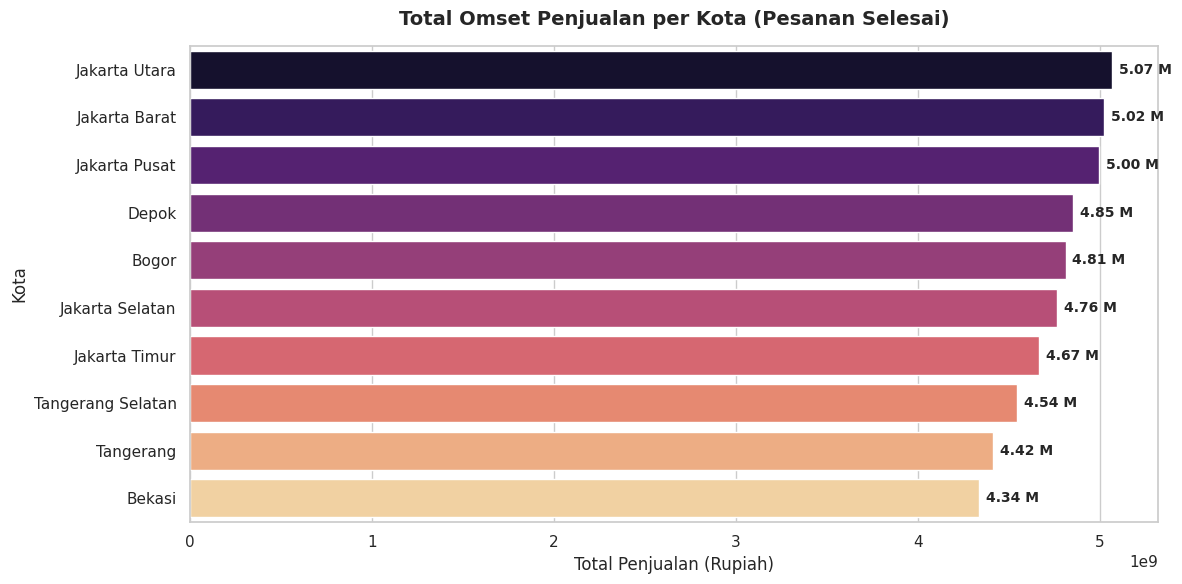

In [32]:
# 4. Buat Bar Chart Mendatar dengan Seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='total_sales',
    y='city',
    data=city_sales,
    palette='magma',
    hue='city',
    legend=False
)

plt.title('Total Omset Penjualan per Kota (Pesanan Selesai)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Penjualan (Rupiah)', fontsize=12)
plt.ylabel('Kota', fontsize=12)

# Sentuhan Akhir: Menambahkan label format Juta (Jt) atau Miliar (M) di ujung batang
for p in ax.patches:
    width = p.get_width()
    if width >= 1_000_000_000:
        label_text = f"{width / 1_000_000_000:.2f} M"
    else:
        label_text = f"{width / 1_000_000:.1f} Jt"

    ax.annotate(
        label_text,
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**Alokasi Anggaran Promo Spesifik Regional (Targeting Kota Terbesar)**

Mengacu pada grafik diatas yang didominasi oleh kota-kota besar (seperti wilayah Jabodetabek), promo diskon besar berikutnya harus diarahkan secara spesifik (geo-targeting) lewat iklan digital ke area-area dengan omset tertinggi tersebut. Manfaatkan efisiensi ongkos kirim ke wilayah kota dominan ini sebagai insentif tambahan (misal: Gratis Ongkir + Diskon Flash Sale) demi memenangkan persaingan pasar furnitur lokal.

**Visualisasi Data:** Menampilkan grafik batang mendatar (*horizontal bar chart*) menggunakan library Seaborn untuk memudahkan komparasi visual kontribusi omset antar kota dalam format nominal Miliar (M).

# **Tantangan 3: Advanced Dashboard Challenge**

In [33]:
# 1. Filter Pesanan Promosi (Status completed dan discount > 0)
df_promo = df_completed[df_completed['discount'] > 0].copy()

In [34]:
# 2. Agregasi Produk
product_agg = df_promo.groupby('product_name').agg(
    total_omset=('total_sales', 'sum'),
    rata_rata_diskon=('discount', 'mean'),
    rata_rata_kuantitas=('quantity', 'mean')
).sort_values(by='total_omset', ascending=False).reset_index()

print("--- Hasil Agregasi Produk dengan Diskon ---")
print(product_agg.to_string(index=False, formatters={
    'total_omset': '{:,.0f}'.format,
    'rata_rata_diskon': '{:,.0f}'.format,
    'rata_rata_kuantitas': '{:.2f}'.format
}))
print("\n")

--- Hasil Agregasi Produk dengan Diskon ---
  product_name total_omset rata_rata_diskon rata_rata_kuantitas
   Kitchen Set 214,530,000                0                1.79
         Kasur 139,400,000                0                2.00
   Lemari Baju 114,480,000                0                1.89
Lemari Sliding 107,435,000                0                2.50
         Bufet 106,270,000                0                2.12
          Sofa 101,870,000                0                2.27
     Lemari TV  79,670,000                0                2.11
  Lemari Dapur  67,880,000                0                1.74
  Lemari Sudut  62,615,000                0                1.92
     Meja Rias  56,125,000                0                1.94
     Meja Kopi  52,760,000                0                2.00
    Meja Makan  49,450,000                0                1.89
     Kursi Bar  38,026,000                0                2.46
   Lemari Laci  33,865,000                0                2

**Filter & Agregasi Promosi:** Menyaring transaksi sukses yang menggunakan potongan harga (`discount > 0`), kemudian menghitung total omset, rata-rata diskon, dan kuantitas belanja per produk.

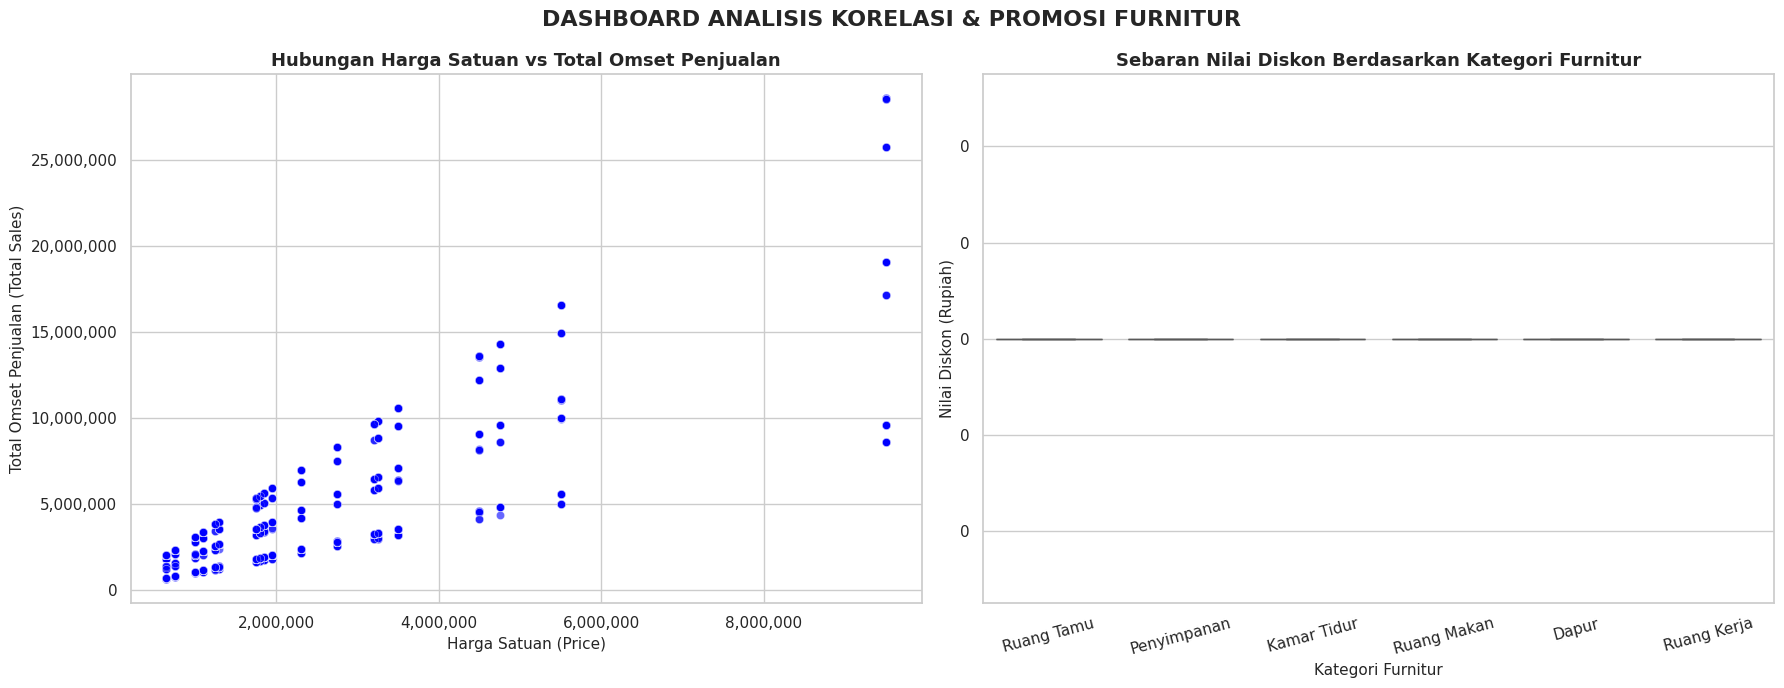

In [38]:
# 3. Desain Dashboard Subplots (1 Baris, 2 Kolom)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Scatter plot antara harga satuan (price) dan total omset (total_sales)
sns.scatterplot(
    ax=axes[0],
    data=df_completed,
    x='price',
    y='total_sales',
    alpha=0.6,
    color='blue',
    edgecolor='w'
)
axes[0].set_title('Hubungan Harga Satuan vs Total Omset Penjualan', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Harga Satuan (Price)', fontsize=11)
axes[0].set_ylabel('Total Omset Penjualan (Total Sales)', fontsize=11)
# Memformat angka sumbu x dan y agar tidak menggunakan notasi ilmiah
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda y, loc: "{:,}".format(int(y))))

# Plot 2: Box plot sebaran diskon (discount) di setiap kategori furnitur
sns.boxplot(
    ax=axes[1],
    data=df_completed[df_completed['discount'] > 0], # Hanya kategori yang ada diskonnya agar visualisasi bersih
    x='category',
    y='discount',
    palette='Set2',
    hue='category',
    legend=False
)
axes[1].set_title('Sebaran Nilai Diskon Berdasarkan Kategori Furnitur', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kategori Furnitur', fontsize=11)
axes[1].set_ylabel('Nilai Diskon (Rupiah)', fontsize=11)
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda y, loc: "{:,}".format(int(y))))
plt.xticks(rotation=15)

plt.suptitle('DASHBOARD ANALISIS KORELASI & PROMOSI FURNITUR', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

**Strategi Bundling & Volume Penjualan untuk Produk Murah**

Dari Scatter Plot terlihat bahwa mayoritas transaksi bertumpuk pada kisaran harga satuan yang lebih rendah, namun mampu menghasilkan total omset yang masif karena volume kuantitasnya yang besar. Tim marketing direkomendasikan untuk membuat paket "Promo Bundling Rumah Baru" (misal: memadukan produk kategori Ruang Tamu dan Kamar Tidur yang berharga murah-sedang) guna mendongkrak kuantitas penjualan sekaligus mempercepat perputaran inventori.

**Evaluasi Batas Atas Diskon Berdasarkan Kategori (Kamar Tidur & Dapur)**


Berdasarkan data Box Plot, sebaran potongan diskon di beberapa kategori utama seperti produk Kamar Tidur dan Dapur memiliki rentang variasi nilai diskon nominal yang cukup tinggi (mencapai angka jutaan rupiah). Untuk mengamankan margin profit perusahaan, tim marketing perlu menetapkan "Maksimal Plafon Diskon Rupiah" (cap discount) agar pemberian promo potongan harga tetap menarik konsumen tanpa menggerus keuntungan produk premium secara berlebihan.

**Dashboard Subplots:**                                                                      
1. *Scatter Plot (Kiri):* Digunakan untuk menganalisis korelasi antara harga satuan barang (`price`) dengan total omset (`total_sales`) untuk melihat rentang harga produk yang paling berkontribusi terhadap pendapatan.
  2. *Box Plot (Kanan):* Digunakan untuk mengidentifikasi sebaran nilai diskon, nilai tengah (*median*), serta variasi potongan harga di setiap kategori furnitur.